## Бібліотеки

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity
from numpy.fft import fft2, ifft2, fftshift, ifftshift
import cv2

## Фільтри 

In [ ]:
# матриця відстаней від центру
def distances_matrix(_fourier):
    M, N = _fourier.shape
    m, n = M // 2, N // 2
    u = np.arange(M).reshape(-1, 1)
    v = np.arange(N).reshape(1, -1)
    return np.sqrt((u - m) ** 2 + (v - n) ** 2)

# загальна функція фільтрації
def frequency_filter(_type, _fourier, _d0, _w=None, _order=None):
    fourier = _fourier.copy()
    distances = distances_matrix(_fourier)
    return filters[_type](fourier, distances,_d0, _w, _order)


# окремі фільтри з різними H:

def ideal_lowpass_filter(_fourier, D, _d0, _w, _order):
    mask = D > _d0
    _fourier[mask] = 1
    return _fourier

def ideal_highpass_filter(_fourier, D, _d0, _w, _order):
    mask = D < _d0
    _fourier[mask] = 1
    return _fourier

def ideal_bandpass_filter(_fourier, D, _d0, _w, _order):
    mask = (D < (_d0 - _w / 2)) | (D > (_d0 + _w / 2)) 
    _fourier[mask] = 1
    return _fourier

def ideal_bandstop_filter(_fourier, D, _d0, _w, _order):
    mask = (D < (_d0 - _w / 2)) | (D > (_d0 + _w / 2)) 
    _fourier[mask] = 1
    return _fourier


def gaussian_lowpass_filter(_fourier, D, _d0, _w, _order):
    H = np.exp(-(D ** 2) / (2 * (_d0 ** 2))) 
    return _fourier*H

def gaussian_highpass_filter(_fourier, D, _d0, _w, _order):
    H = 1 - np.exp(-(D ** 2) / (2 * (_d0 ** 2)))
    return _fourier*H

def gaussian_bandstop_filter(_fourier, D, _d0, _w, _order):
    H = 1 - np.exp(- ((D**2 - _d0**2) ** 2) / (2 * (_w ** 2) * D**2 + 1e-5))  # 1е-5 для уникнення ділення на 0
    return _fourier*H

def gaussian_bandpass_filter(_fourier, D, _d0, _w, _order):
    H = np.exp(- ((D**2 - _d0**2) ** 2) / (2 * (_w ** 2) * D**2 + 1e-5))  
    return _fourier*H


def butterworth_lowpass_filter(_fourier, D, _d0, _w, _order):
    H = 1 / (1 + ( D / _d0)**(2 * _order))
    return _fourier * H

def butterworth_highpass_filter(_fourier, D, _d0, _w, _order):
    H = 1 / (1 + (_d0 / (D + 1e-5))**(2 * _order)) 
    return _fourier * H

def butterworth_bandstop_filter(_fourier, D, _d0, _w, _order):
    H = 1 / (1 + ((_w * D) / (D**2 - _d0**2 + 1e-5))**(2 * _order)) 
    return _fourier * H

def butterworth_bandpass_filter(_fourier, D, _d0, _w, _order):
    H = 1 / (1 + ((_w * D) / (D**2 - _d0**2 + 1e-5))**(2 * _order))  
    H = 1 - H  # band-stop до band-pass
    return _fourier * H

def laplacian_filter(_fourier, D, _d0, _w, _order):
    H = -4 * (np.pi ** 2) * (D ** 2)
    return _fourier * H

def log_filter(_fourier, D, _d0, _w, _order):
    H = -4 * (np.pi ** 2) * (D ** 2) * np.exp(-2 * (np.pi ** 2) * (D ** 2) / (_d0 ** 2))
    return _fourier * H

# перелік функцій для фільтрації
filters = {
    "З ідеальним зрізом | З пропуском низьких частот":ideal_lowpass_filter,
    "З ідеальним зрізом | З пропуском високих частот":ideal_highpass_filter,
    "З ідеальним зрізом | Смуговий 1":ideal_bandpass_filter,
    "З ідеальним зрізом | Смуговий 2":ideal_bandstop_filter,
    "Гауса | З пропуском низьких частот":gaussian_lowpass_filter,
    "Гауса | З пропуском високих частот":gaussian_highpass_filter,
    "Гауса | Смуговий 1":gaussian_bandpass_filter,
    "Гауса | Смуговий 2":gaussian_bandstop_filter,
    "Баттерворта | З пропуском низьких частот":butterworth_lowpass_filter,
    "Баттерворта | З пропуском високих частот":butterworth_highpass_filter,
    "Баттерворта | Смуговий 1":butterworth_bandpass_filter,
    "Баттерворта | Смуговий 2":butterworth_bandstop_filter,
    "Лапласа | З пропуском низьких частот": laplacian_filter,
    "Лапласа від Гауса | З пропуском низьких частот": log_filter
}

def apply_filter(img, filter_name, d0=30, w=10, order=2):
    f = fftshift(fft2(img))
    filtered = frequency_filter(filter_name, f, d0, w, order)
    result = np.real(ifft2(ifftshift(filtered)))
    return np.clip(result, 0, 255)


## Додавання шуму

In [ ]:
def add_gaussian_noise(img, sigma=20):
    noise = np.random.normal(0, sigma, img.shape)
    noisy = img + noise
    return np.clip(noisy, 0, 255)


def add_salt_noise(image, amount=0.02):
    image = image.astype(np.float32) / 255
    noisy = image.copy()
    num_salt = np.ceil(amount * image.size * 0.5)
    num_pepper = np.ceil(amount * image.size * 0.5)

    coords = tuple(np.random.randint(0, i - 1, int(num_salt)) for i in image.shape)
    noisy[coords] = 1

    coords = tuple(np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape)
    noisy[coords] = 0
    return np.clip(noisy, 0, 1) * 255

def add_speckle_noise(img, std=0.1):
    noise = np.random.normal(0, std, img.shape)
    noisy = img + img * noise
    return np.clip(noisy, 0, 255)

def add_poisson_noise(img):
    noisy = np.random.poisson(img).astype(np.float64)
    return np.clip(noisy, 0, 255)

def add_uniform_noise(img, low=-50, high=50):
    noise = np.random.uniform(low, high, img.shape)
    noisy = img + noise
    return np.clip(noisy, 0, 255)

def add_periodic_noise(img, amplitude=40, freq=10):
    M, N = img.shape
    u = np.arange(M).reshape(-1, 1)
    periodic = amplitude * np.cos(2 * np.pi * freq * u)
    noisy = img + periodic
    return np.clip(noisy, 0, 255)

## Порівняння згладжування (відновлення від шуму)

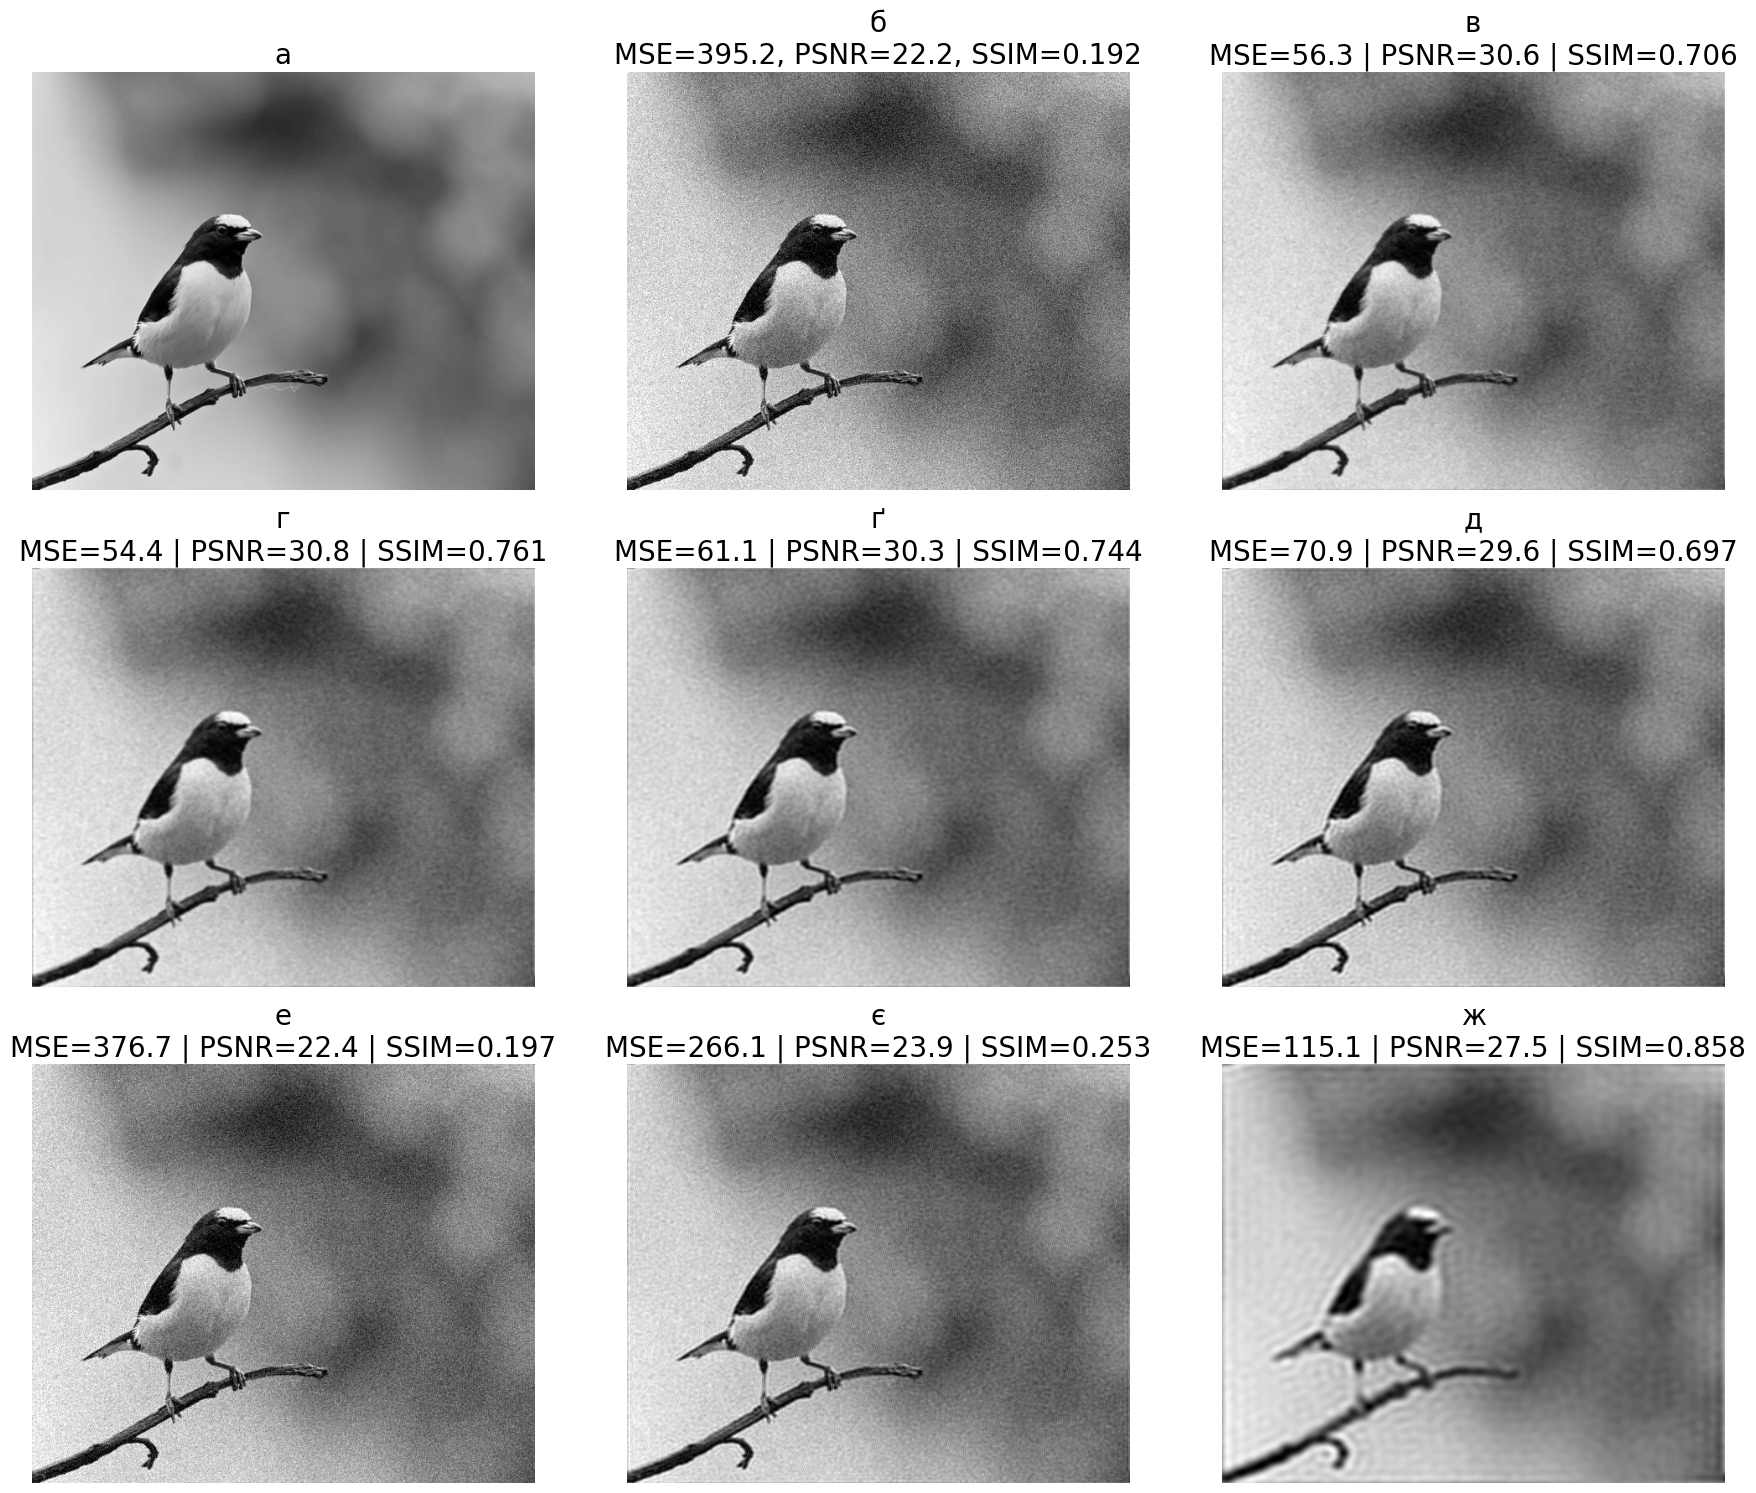

In [ ]:
# ---------- Метрики ----------------------------------------------------------------------------------------------------

def compute_metrics(original, processed):
    mse = mean_squared_error(original, processed)
    psnr = peak_signal_noise_ratio(original, processed, data_range=255)
    ssim = structural_similarity(original, processed, data_range=255)
    return mse, psnr, ssim


# ---------- Побудова сітки -----------------------------------------------------------------------------------------------

def show_results(original_img, noisy_img, filters_to_apply, noise_sigma=50):

    cols = 3
    rows = 1 + int(np.ceil(len(filters_to_apply) / cols))

    plt.figure(figsize=(6 * cols, 5 * rows))

    # --- ОРИГІНАЛ ---
    plt.subplot(rows, cols, 1)
    plt.imshow(original_img, cmap='gray')
    plt.title("a", fontsize=20)
    plt.axis("off")

    # --- ШУМ ---
    plt.subplot(rows, cols, 2)
    plt.imshow(noisy_img, cmap='gray')
    mse, psnr, ssim = compute_metrics(original_img, noisy_img)
    plt.title(f"б\nMSE={mse:.1f}, PSNR={psnr:.1f}, SSIM={ssim:.3f}", fontsize=20)
    plt.axis("off")


    # --- ФІЛЬТРИ ---
    for i, f in enumerate(filters_to_apply):
        symbol, f_name, d0, w, order = f
        processed = apply_filter(noisy_img, f_name, d0, w, order)

        mse, psnr, ssim = compute_metrics(original_img, processed)

        plt.subplot(rows, cols, cols + i)
        plt.imshow(processed, cmap="gray")
        if i==3:
            cv2.imwrite("images/orig13.png", processed)
        plt.title(
            f"{symbol}\nMSE={mse:.1f} | PSNR={psnr:.1f} | SSIM={ssim:.3f}",
            fontsize=20
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


filters_to_apply = [
    ("в", "Гауса | З пропуском низьких частот", 90, None, None),
    ("г", "Баттерворта | З пропуском низьких частот", 90, None, 2),
    ("ґ","Баттерворта | З пропуском низьких частот", 90, None, 5),
    ("д", "З ідеальним зрізом | З пропуском низьких частот", 90, None, None),
    ("е", "Гауса | Смуговий 2", 150, 100, None),
    ("є","Баттерворта | Смуговий 2", 150, 100, 5),
    ("ж", "З ідеальним зрізом | Смуговий 2", 150, 100, None)
]


ideal =  cv2.imread("images/test4.jpg", cv2.IMREAD_GRAYSCALE)
image =  add_gaussian_noise(ideal)
show_results(ideal, image, filters_to_apply)


## Порівняння виділення країв

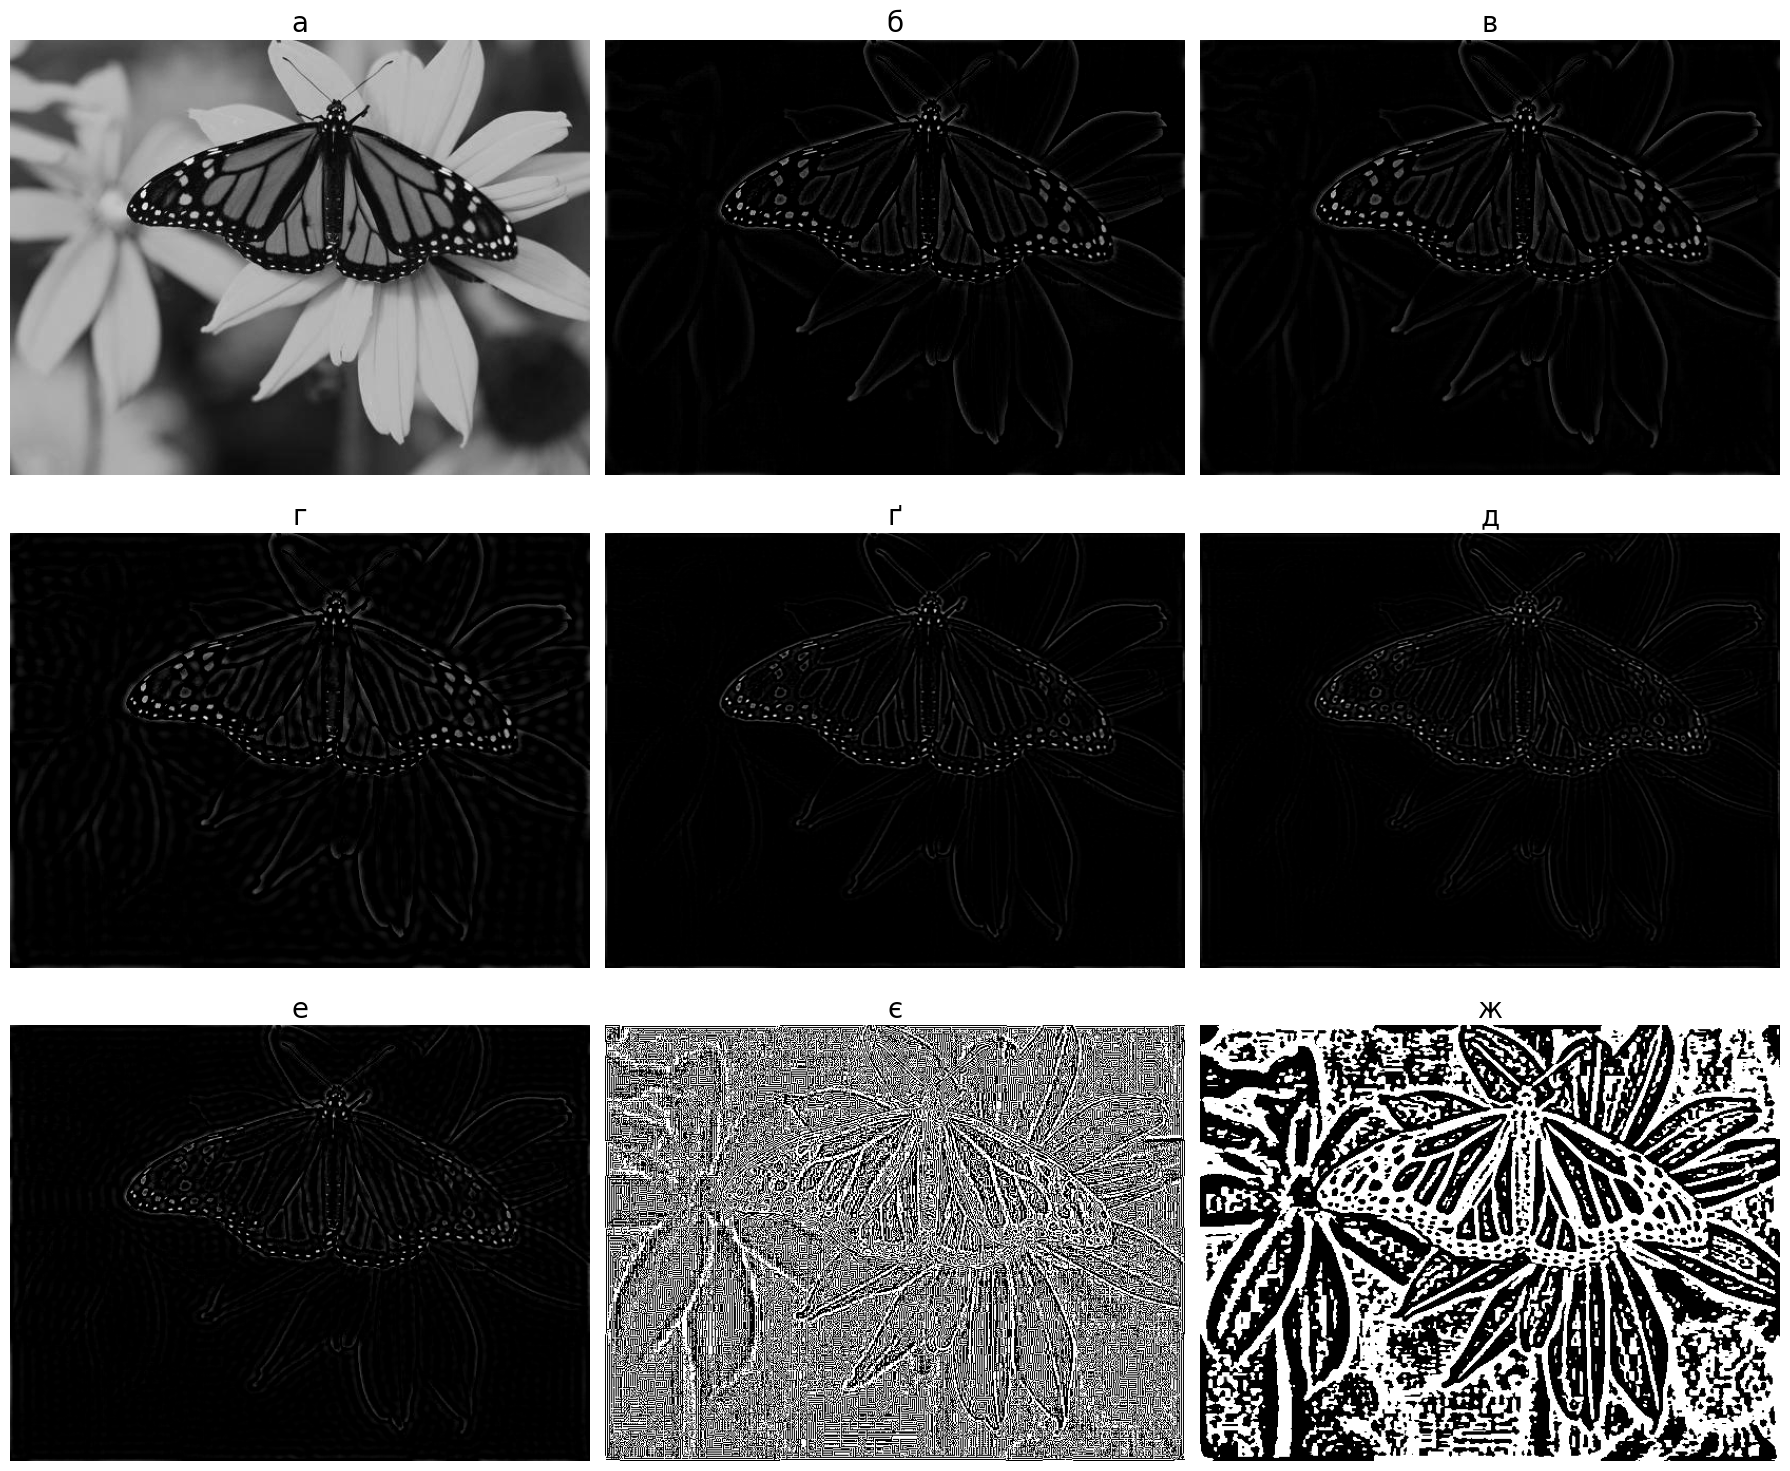

In [ ]:

# ---------- Побудова сітки ---------------------------------------------------------------------------------------------

def show_results(original_img, filters_to_apply, noise_sigma=50):

    cols = 3
    rows = 1 + int(np.ceil(len(filters_to_apply) / cols))

    plt.figure(figsize=(6 * cols, 5 * rows))

    # --- ОРИГІНАЛ ---
    plt.subplot(rows, cols, 1)
    plt.imshow(original_img, cmap='gray')
    plt.title("a", fontsize=20)
    plt.axis("off")


    # --- ФІЛЬТРИ ---
    for i, f in enumerate(filters_to_apply):
        symbol, f_name, d0, w, order = f
        processed = apply_filter(original_img, f_name, d0, w, order)


        plt.subplot(rows, cols, cols + i - 1)
        plt.imshow(processed, cmap="gray")
        if i==3:
            cv2.imwrite("images/orig13.png", processed)
        plt.title(
            f"{symbol}",
            fontsize=20
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()



filters_to_apply = [
    ("б", "Гауса | З пропуском високих частот", 30, None, None),
    ("в", "Баттерворта | З пропуском високих частот", 30, None, 2),
    ("г", "З ідеальним зрізом | З пропуском високих частот", 30, None, None),
    ("ґ", "Гауса | Смуговий 1", 100, 100, None),
    ("д","Баттерворта | Смуговий 1", 100, 100, 5),
    ("е", "З ідеальним зрізом | Смуговий 1", 200, 300, None),
    ("є", "Лапласа | З пропуском низьких частот", 100, None, None),
    ("ж", "Лапласа від Гауса | З пропуском низьких частот", 300, None, None)
]

image =  cv2.imread("images/test.jpg", cv2.IMREAD_GRAYSCALE)
show_results(image, filters_to_apply)


## Порівняння покращення чіткості

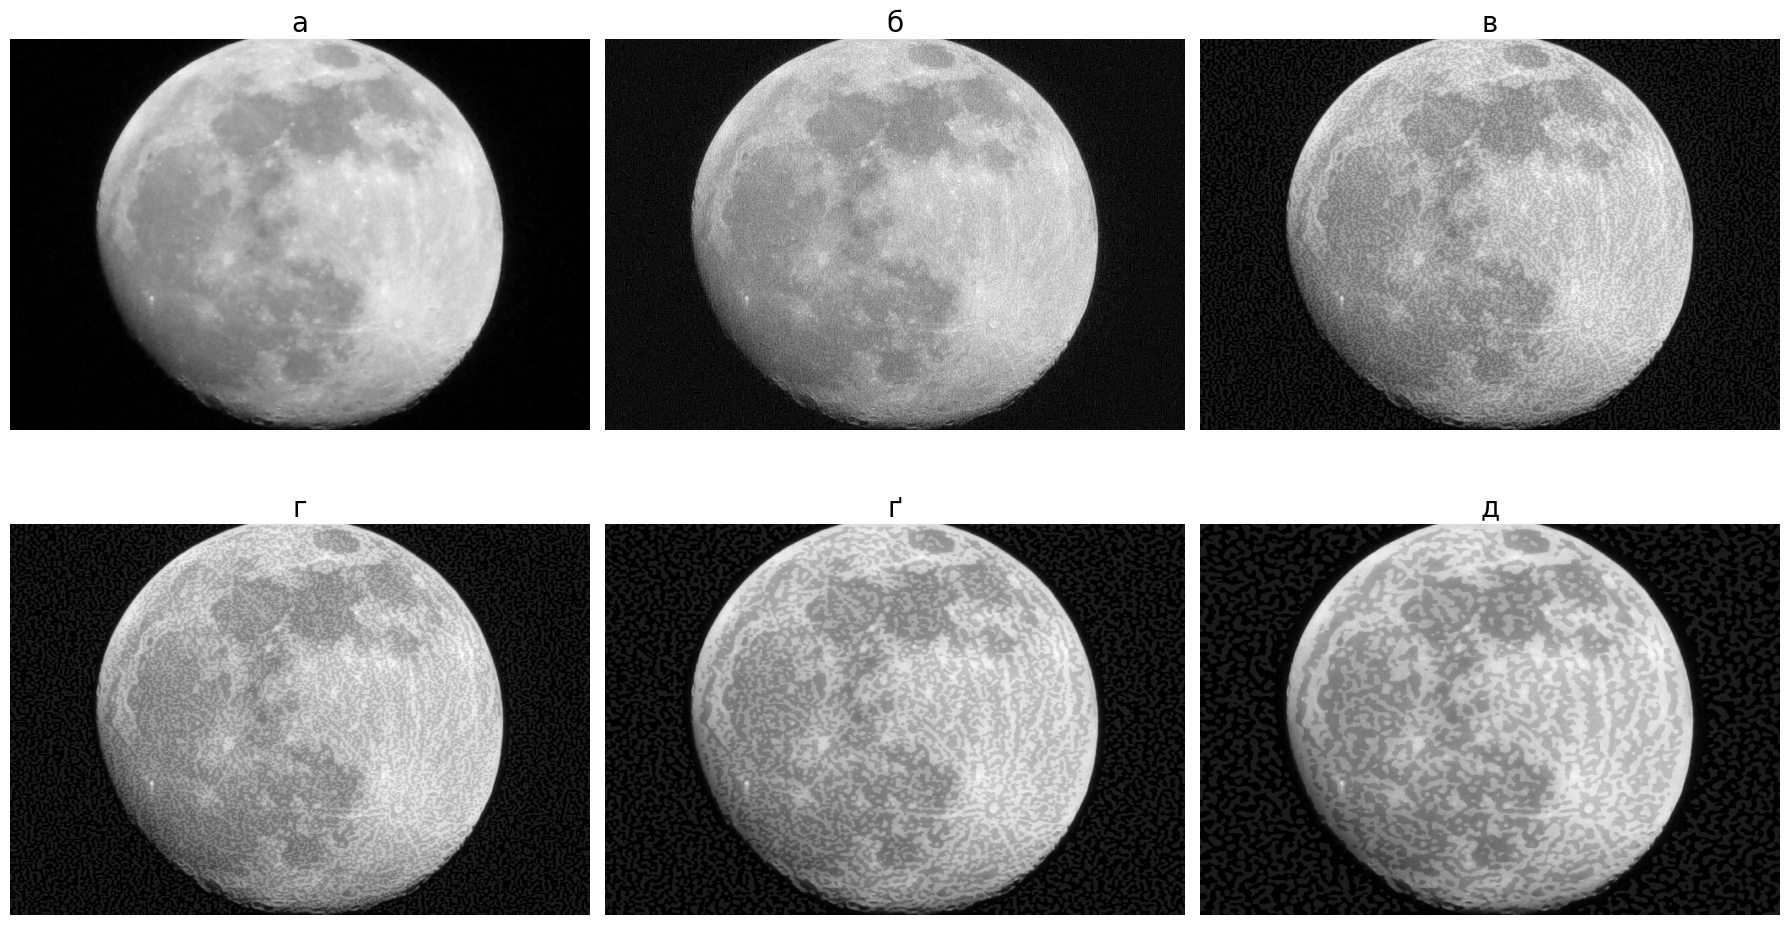

In [ ]:
# ---------- Побудова сітки ----------------------------------------------------------------------------------

def show_results(original_img, filters_to_apply, noise_sigma=50):

    cols = 3
    rows = 1 + int(np.ceil(len(filters_to_apply) / cols))

    plt.figure(figsize=(6 * cols, 5 * rows))

    # --- ОРИГІНАЛ ---
    plt.subplot(rows, cols, 1)
    plt.imshow(original_img, cmap='gray')
    plt.title("a", fontsize=20)
    plt.axis("off")


    # --- ФІЛЬТРИ ---
    for i, f in enumerate(filters_to_apply):
        symbol, f_name, d0, w, order = f
        processed = apply_filter(original_img, f_name, d0, w, order)
        processed = original_img + -0.1*processed

        plt.subplot(rows, cols, cols + i - 1)
        plt.imshow(processed, cmap="gray")
        plt.title(
            f"{symbol}",
            fontsize=20
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()



filters_to_apply = [
    ("б", "Лапласа | З пропуском низьких частот", None, None, None),
    ("в", "Лапласа від Гауса | З пропуском низьких частот", 600, None, None),
    ("г", "Лапласа від Гауса | З пропуском низьких частот", 500, None, None),
    ("ґ", "Лапласа від Гауса | З пропуском низьких частот", 300, None, None),
    ("д", "Лапласа від Гауса | З пропуском низьких частот", 200, None, None)
]

image =  cv2.imread("images/moon.jpg", cv2.IMREAD_GRAYSCALE)
show_results(image, filters_to_apply)